In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit
from iminuit import cost
from scipy import stats
from helpers import *
from sympy import * 
import pandas as pd
r = np.random 
r.seed(42)

## 4.1.1

In [2]:
dataframe = pd.read_csv('Data/data_BloodPressure.csv', header=0)
ptype, bloodp = dataframe.values.T
healthy = bloodp[ptype == 0]
hyper = bloodp[ptype == 1]
hypo = bloodp[ptype == 2]
sick = np.concatenate((hyper, hypo))
print(f"Number of healthy patients: {len(healthy)}")
print(f"Number of sick patients: {len(sick)}")

Number of healthy patients: 1533
Number of sick patients: 965


In [3]:
mu_healthy, unc_healthy = compiler_esti(healthy)
std_healthy = np.std(healthy)
print(f"Healthy: Mean = {mu_healthy:.1f} ± {unc_healthy:.1f}")
C_lower = mu_healthy - 1.96 * std_healthy
C_upper = mu_healthy + 1.96 * std_healthy
print(f"95% confidence interval for Healthy: ({C_lower:.1f}, {C_upper:.1f})")
mask = (healthy > C_lower) & (healthy < C_upper)
healthy_filtered = healthy[mask]
print(f"Percentage of healthy patients in confidence interval: {len(healthy_filtered) / len(healthy) * 100:.2f}%")

Healthy: Mean = 120.7 ± 0.3
95% confidence interval for Healthy: (101.0, 140.3)
Percentage of healthy patients in confidence interval: 95.50%


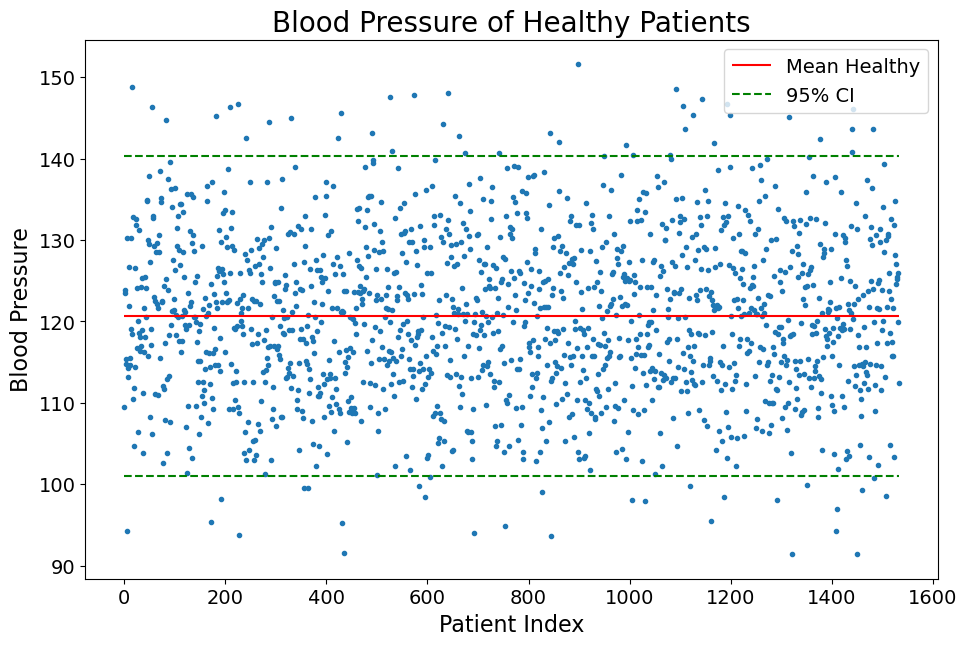

In [4]:
fig,ax = plt.subplots(figsize=(11,7))
xx = np.arange(len(healthy))
ax.plot(xx, healthy, '.')
ax.hlines(mu_healthy, 0, len(healthy), colors='r', label='Mean Healthy')
ax.hlines([C_lower, C_upper], 0, len(healthy), colors='g', linestyles='dashed', label='95% CI')
ax.set_xlabel('Patient Index', fontsize=16)
ax.set_ylabel('Blood Pressure', fontsize=16)
ax.set_title('Blood Pressure of Healthy Patients', fontsize=20)
ax.legend(fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=14);

## 4.1.2

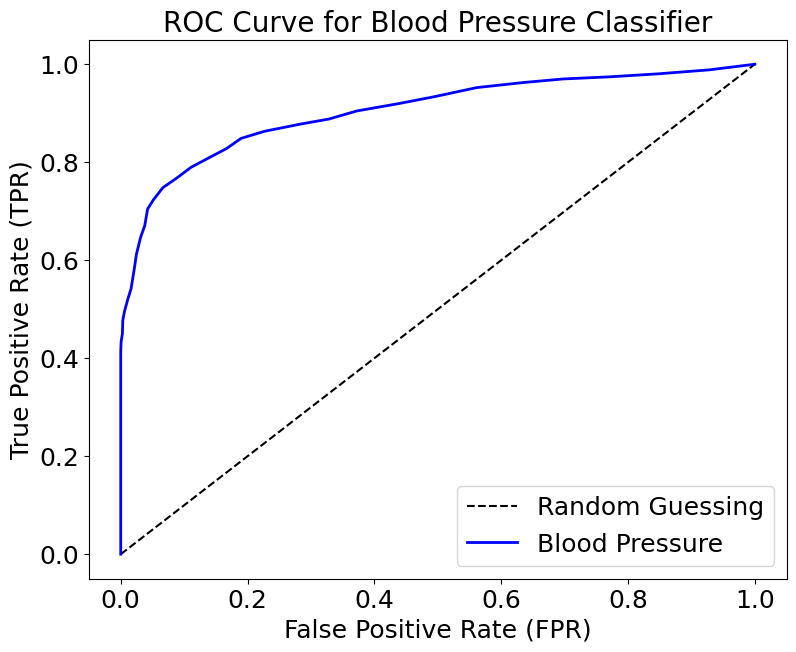

In [5]:
d_sick = np.abs(sick - mu_healthy)
d_healthy = np.abs(healthy - mu_healthy)

threshold = np.linspace(0, 100, 101)
TPR_vals = np.zeros(len(threshold))
FPR_vals = np.zeros(len(threshold))

for i in range(len(threshold)):
    TPR = np.sum(d_sick > threshold[i]) / len(sick)
    FPR = np.sum(d_healthy > threshold[i]) / len(healthy)
    TPR_vals[i] = TPR
    FPR_vals[i] = FPR
fig, ax = plt.subplots(figsize=(9, 7))
ax.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
ax.plot(FPR_vals, TPR_vals, color='blue', lw=2, label='Blood Pressure')
ax.set_xlabel('False Positive Rate (FPR)', fontsize=18)
ax.set_ylabel('True Positive Rate (TPR)', fontsize=18)
ax.set_title('ROC Curve for Blood Pressure Classifier', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.legend(fontsize=18);

## 4.1.3

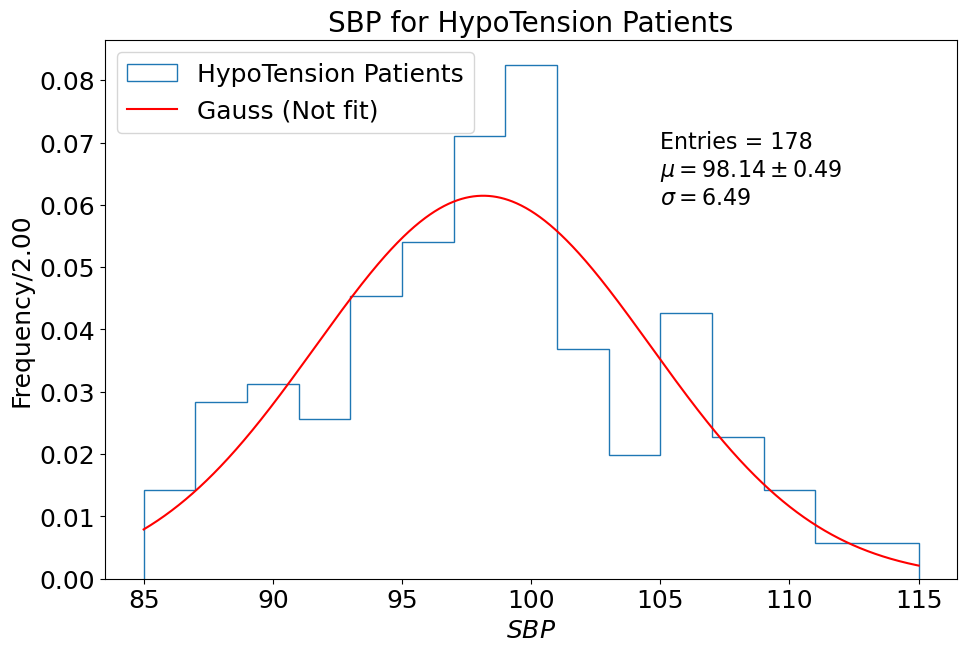

In [6]:
xmin = 85
xmax = 115
Nbins = 15
binwidth = (xmax - xmin) / Nbins
mu_hypo = np.mean(hypo)
std_hypo = np.std(hypo)
x_axis = np.linspace(xmin, xmax, 1000)

fig, ax = plt.subplots(figsize=(11, 7))
ax.hist(hypo, bins=Nbins, density=True, range=(xmin, xmax), histtype='step', label='HypoTension Patients')
ax.plot(x_axis, stats.norm.pdf(x_axis, loc=mu_hypo, scale=std_hypo), 'r-', label="Gauss (Not fit)")
ax.set_xlabel(r'$SBP$', fontsize=18)
ax.set_ylabel(f'Frequency/{binwidth:.2f}', fontsize=18)
ax.set_title('SBP for HypoTension Patients', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.text(105, 0.06, fr'Entries = {len(hypo)}' + '\n' + fr'$\mu={mu_hypo:.2f} \pm {std_hypo/np.sqrt(len(hypo)):.2f}$' + '\n' + fr'$\sigma={std_hypo:.2f}$', fontsize=16);
ax.legend(fontsize=18);

In [7]:
p_98H2 = stats.norm.pdf(98, loc=mu_hypo, scale=std_hypo)
print(p_98H2)
p_98H1 = stats.norm.pdf(98, loc=mu_healthy, scale=std_healthy)
print(p_98H1)
p_H298 = (p_98H2 / (p_98H2 + p_98H1))
print((0.06145)/(0.06145 + 0.00311))
print(f"Probability of being H2 given SBP=98: {p_H298:.6f}")

0.06145152564790868
0.003111868698681675
0.951827757125155
Probability of being H2 given SBP=98: 0.951801


## 4.1.4

In [8]:
PH2 = len(hypo) / len(bloodp)
PH1 = len(healthy) / len(bloodp)
print(PH2, PH1)
p_H298_data = (p_98H2 * PH2) / (p_98H2 * PH2 + p_98H1 * PH1)
print(f"Probability of being H2 given SBP=98 (with prior from data): {p_H298_data:.5f}")

0.07125700560448359 0.6136909527622098
Probability of being H2 given SBP=98 (with prior from data): 0.69632


## 4.1.5

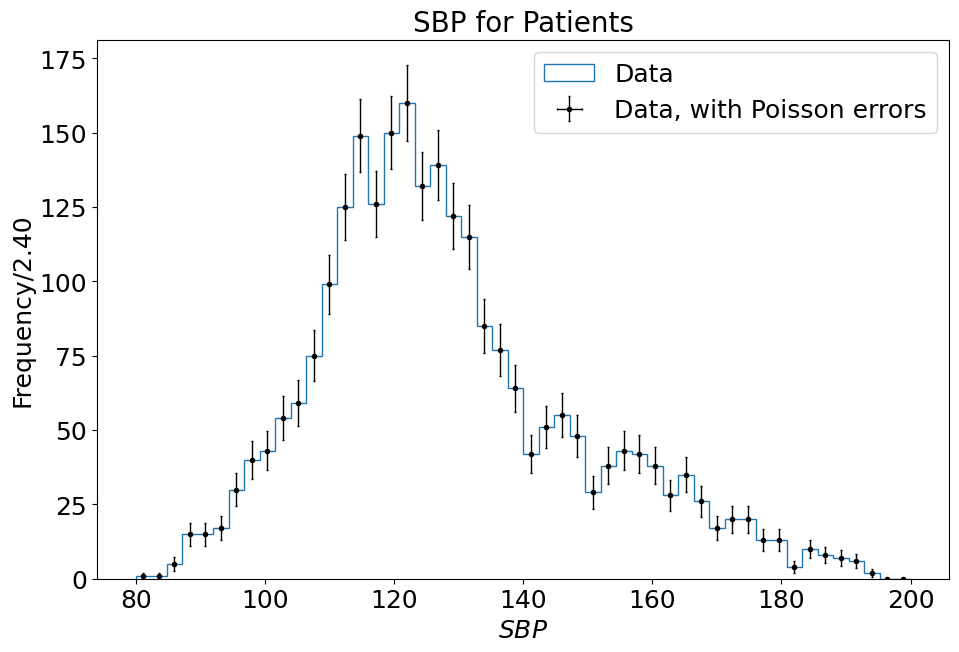

In [9]:
xmin = 80
xmax = 200
Nbins = 50
binwidth = (xmax - xmin) / Nbins

fig, ax = plt.subplots(figsize=(11, 7))
ax.hist(bloodp, bins=Nbins, range=(xmin, xmax), histtype='step', label='Data')
counts, bin_edges = np.histogram(bloodp, bins=Nbins, range=(xmin, xmax))
x = (bin_edges[1:] + bin_edges[:-1])/2
y = counts    
sy = np.sqrt(counts) 
ax.errorbar(x, y, yerr=sy, xerr=0.0, label='Data, with Poisson errors', fmt='.k',  ecolor='k', elinewidth=1, capsize=1, capthick=1)

ax.set_xlabel(r'$SBP$', fontsize=18)
ax.set_ylabel(f'Frequency/{binwidth:.2f}', fontsize=18)
ax.set_title('SBP for Patients', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.legend(fontsize=18);

In [10]:
print(len(y[y>5])/50)

0.86


### Fitting with complicated pdf

In [11]:
def weibull_pdf(x, N, lam, k):
    return N * ((k / lam) * (x / lam)**(k - 1) * np.exp(-(x / lam)**k)) * binwidth

def weibull_llh(x, N, lam, k):
    return N,  N * ((k / lam) * (x / lam)**(k - 1) * np.exp(-(x / lam)**k))

In [12]:
x_chi = x[y > 0]
y_chi = y[y > 0]
sy_chi = sy[y > 0]

cfit_wei2 = cost.LeastSquares(x_chi, y_chi, sy_chi, weibull_pdf)
mfit_wei2 = Minuit(cfit_wei2, N=len(bloodp), lam=130, k=11)
mfit_wei2.migrad()
chi2 = mfit_wei2.fval
ndof = len(x_chi) - mfit_wei2.nfit
prob = stats.chi2.sf(chi2, ndof)
print(f"Chi2 / ndof = {chi2:.2f} / {ndof} = {chi2/ndof:.2f}, p-value = {prob:.20f}")
cfit_weillh = cost.ExtendedUnbinnedNLL(bloodp, weibull_llh)
mfit_weillh = Minuit(cfit_weillh, N=len(bloodp), lam=130, k=11)
mfit_weillh.migrad();

Chi2 / ndof = 563.01 / 45 = 12.51, p-value = 0.00000000000000000000


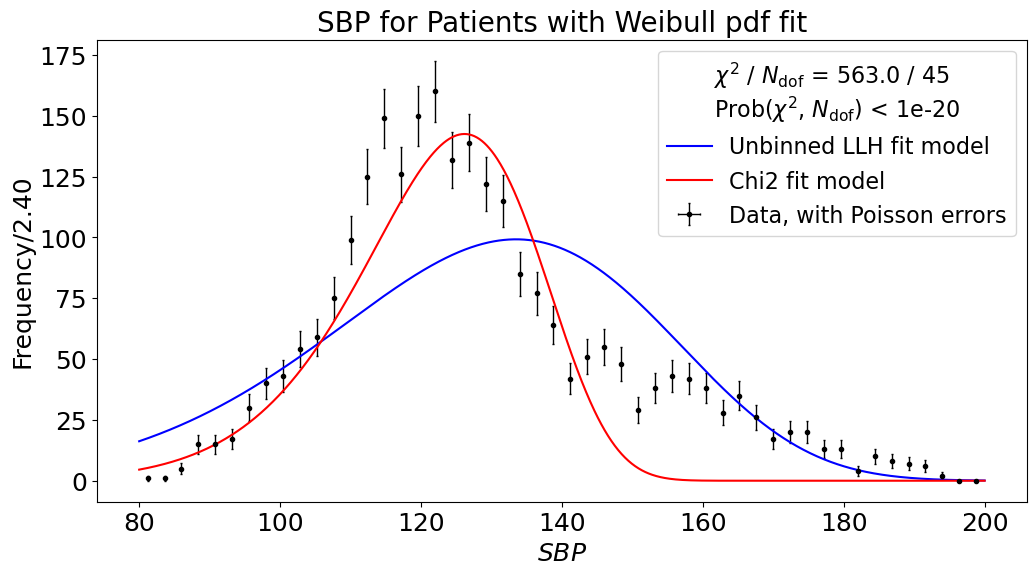

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.errorbar(x, y, yerr=sy, xerr=0.0, label='Data, with Poisson errors', fmt='.k',  ecolor='k', elinewidth=1, capsize=1, capthick=1)

ax.set_xlabel(r'$SBP$', fontsize=18)
ax.set_ylabel(f'Frequency/{binwidth:.2f}', fontsize=18)
ax.set_title('SBP for Patients with Weibull pdf fit', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=18)
xx = np.linspace(xmin, xmax, 1000)
ax.plot(xx, weibull_pdf(xx, *mfit_weillh.values[:]), '-b', label='Unbinned LLH fit model')
ax.plot(xx, weibull_pdf(xx, *mfit_wei2.values[:]), '-r', label='Chi2 fit model')
fit_info = [f"$\\chi^2$ / $N_\\mathrm{{dof}}$ = {chi2:.1f} / {ndof}", f"Prob($\\chi^2$, $N_\\mathrm{{dof}}$) < {10**-20}",]

plt.legend(title="\n".join(fit_info), fontsize=16, title_fontsize = 16, alignment = 'center');

In [14]:
def inv_gammapdf(x, N, a, alpha, beta):
    return N*binwidth*stats.gamma.pdf(x, a, alpha, beta)
def inv_gamma_llh(x, N, a, alpha, beta):
    return N, N*stats.gamma.pdf(x, a, alpha, beta)

In [15]:
cfit_invg2 = cost.LeastSquares(x_chi, y_chi, sy_chi, inv_gammapdf)
mfit_invg2 = Minuit(cfit_invg2, N=len(bloodp), a= 5, alpha=100, beta=10)
mfit_invg2.migrad()
chi2 = mfit_invg2.fval
ndof = len(x_chi) - mfit_invg2.nfit
prob = stats.chi2.sf(chi2, ndof)
print(f"Chi2 / ndof = {chi2:.2f} / {ndof} = {chi2/ndof:.2f}, p-value = {prob:.10f}")
cfit_invgllh = cost.ExtendedUnbinnedNLL(bloodp, inv_gamma_llh)
mfit_invgllh = Minuit(cfit_invgllh,  N=len(bloodp), a= 5, alpha=100, beta=10)
mfit_invgllh.migrad();

Chi2 / ndof = 144.54 / 44 = 3.28, p-value = 0.0000000000


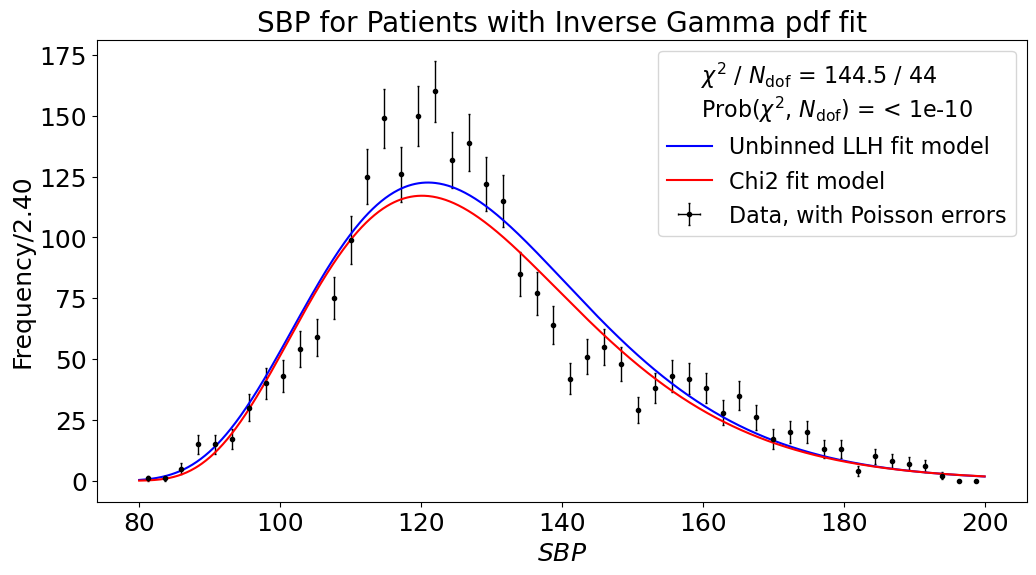

In [16]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.errorbar(x, y, yerr=sy, xerr=0.0, label='Data, with Poisson errors', fmt='.k',  ecolor='k', elinewidth=1, capsize=1, capthick=1)

ax.set_xlabel(r'$SBP$', fontsize=18)
ax.set_ylabel(f'Frequency/{binwidth:.2f}', fontsize=18)
ax.set_title('SBP for Patients with Inverse Gamma pdf fit', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=18)
xx = np.linspace(xmin, xmax, 1000)
ax.plot(xx, inv_gammapdf(xx, *mfit_invgllh.values[:]), '-b', label='Unbinned LLH fit model')
ax.plot(xx, inv_gammapdf(xx, *mfit_invg2.values[:]), '-r', label='Chi2 fit model')
fit_info = [f"$\\chi^2$ / $N_\\mathrm{{dof}}$ = {chi2:.1f} / {ndof}", f"Prob($\\chi^2$, $N_\\mathrm{{dof}}$) = < {10**-10}",]

plt.legend(title="\n".join(fit_info), fontsize=16, title_fontsize = 16, alignment = 'center');

### Fitting with more standard pdfs

In [17]:
def gauss(x, N, mu, sigma):
    return N*binwidth*stats.norm.pdf(x, mu, sigma)

def gauss_llh(x, N, mu, sigma):
    return N, N*stats.norm.pdf(x, mu, sigma)

#### $H_0$

In [18]:
xmin_0 = 90
xmax_0 = 150
Nbins = 30
binwidth = (xmax_0 - xmin_0) / Nbins
print(binwidth)

# fig, ax = plt.subplots(figsize=(11, 7))
# ax.hist(healthy, bins=Nbins, range=(xmin, xmax), histtype='step', label='Data')
counts, bin_edges = np.histogram(healthy, bins=Nbins, range=(xmin_0, xmax_0))
x_0 = (bin_edges[1:] + bin_edges[:-1])/2
y_0 = counts    
sy_0 = np.sqrt(counts) 
# ax.errorbar(x_0, y_0, yerr=sy_0, xerr=0.0, label='Data, with Poisson errors', fmt='.k',  ecolor='k', elinewidth=1, capsize=1, capthick=1)

# ax.set_xlabel(r'$SBP$', fontsize=18)
# ax.set_ylabel(f'Frequency/{binwidth:.2f}', fontsize=18)
# ax.set_title('SBP for Patients', fontsize=20)
# ax.tick_params(axis='both', which='major', labelsize=18)
# ax.legend(fontsize=18);

2.0


In [19]:
x0_chi = x_0[y_0 > 0]
y0_chi = y_0[y_0 > 0]
sy0_chi = sy_0[y_0 > 0]

cfit2_h0 = cost.LeastSquares(x0_chi, y0_chi, sy0_chi, gauss)
mfit2_h0 = Minuit(cfit2_h0, N=len(healthy), mu=np.mean(healthy), sigma=np.std(healthy))
mfit2_h0.migrad()
chi2 = mfit2_h0.fval 
Ndof = len(x0_chi) - mfit2_h0.nfit
Prob = stats.chi2.sf(chi2, Ndof)
print(f"Chi2 / ndof = {chi2:.2f} / {Ndof} = {chi2/Ndof:.2f}, p-value = {Prob:.4f}")
cfitllh_h0 = cost.ExtendedUnbinnedNLL(healthy, gauss_llh)
mfitllh_h0 = Minuit(cfitllh_h0,  N=len(healthy), mu=np.mean(healthy), sigma=np.std(healthy))
mfitllh_h0.migrad();

Chi2 / ndof = 63.04 / 27 = 2.33, p-value = 0.0001


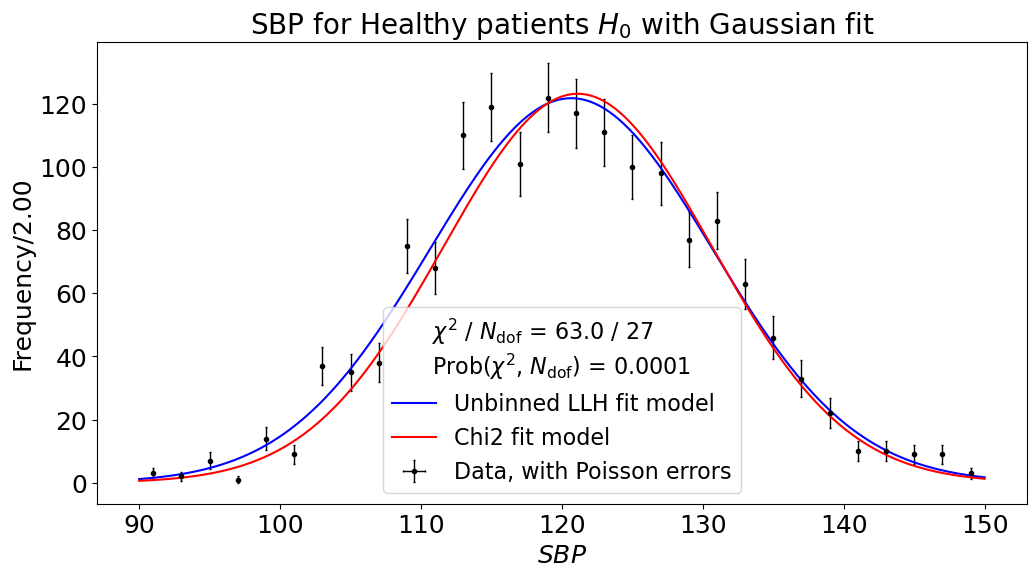

In [20]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.errorbar(x_0, y_0, yerr=sy_0, xerr=0.0, label='Data, with Poisson errors', fmt='.k',  ecolor='k', elinewidth=1, capsize=1, capthick=1)
ax.set_xlabel(r'$SBP$', fontsize=18)
ax.set_ylabel(f'Frequency/{binwidth:.2f}', fontsize=18)
ax.set_title('SBP for Healthy patients $H_0$ with Gaussian fit', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=18)
xx = np.linspace(xmin_0, xmax_0, 1000)
ax.plot(xx, gauss(xx, *mfitllh_h0.values[:]), '-b', label='Unbinned LLH fit model')
ax.plot(xx, gauss(xx, *mfit2_h0.values[:]), '-r', label='Chi2 fit model')
# Adding fit results to plot:
chi2 = mfit2_h0.fval 
Ndof = len(x0_chi) - mfit2_h0.nfit
Prob = stats.chi2.sf(chi2, Ndof)

fit_info = [f"$\\chi^2$ / $N_\\mathrm{{dof}}$ = {chi2:.1f} / {Ndof}", f"Prob($\\chi^2$, $N_\\mathrm{{dof}}$) = {Prob:.4f}",]

plt.legend(title="\n".join(fit_info), fontsize=16, title_fontsize = 16, alignment = 'center');

#### $H_1$

In [21]:
xmin_1 = 85
xmax_1 = 205
Nbins = 30
binwidth = (xmax_1 - xmin_1) / Nbins

# fig, ax = plt.subplots(figsize=(11, 7))
ax.hist(hyper, bins=Nbins, range=(xmin_1, xmax_1), histtype='step', label='Data')
counts, bin_edges = np.histogram(hyper, bins=Nbins, range=(xmin_1, xmax_1))
x_1 = (bin_edges[1:] + bin_edges[:-1])/2
y_1 = counts    
sy_1 = np.sqrt(counts) 
# ax.errorbar(x_1, y_1, yerr=sy_1, xerr=0.0, label='Data, with Poisson errors', fmt='.k',  ecolor='k', elinewidth=1, capsize=1, capthick=1)

# ax.set_xlabel(r'$SBP$', fontsize=18)
# ax.set_ylabel(f'Frequency/{binwidth:.2f}', fontsize=18)
# ax.set_title('SBP for HyperTension Patients', fontsize=20)
# ax.tick_params(axis='both', which='major', labelsize=18)
# ax.legend(fontsize=18);

In [22]:
x1_chi = x_1[y_1 > 0]
y1_chi = y_1[y_1 > 0]
sy1_chi = sy_1[y_1 > 0]

cfit2_h1 = cost.LeastSquares(x1_chi, y1_chi, sy1_chi, gauss)
mfit2_h1 = Minuit(cfit2_h1, N=len(hyper), mu=np.mean(hyper), sigma=np.std(hyper))
mfit2_h1.migrad()
cfitllh_h1 = cost.ExtendedUnbinnedNLL(hyper, gauss_llh)
mfitllh_h1 = Minuit(cfitllh_h1,  N=len(hyper), mu=np.mean(hyper), sigma=np.std(hyper))
mfitllh_h1.migrad();

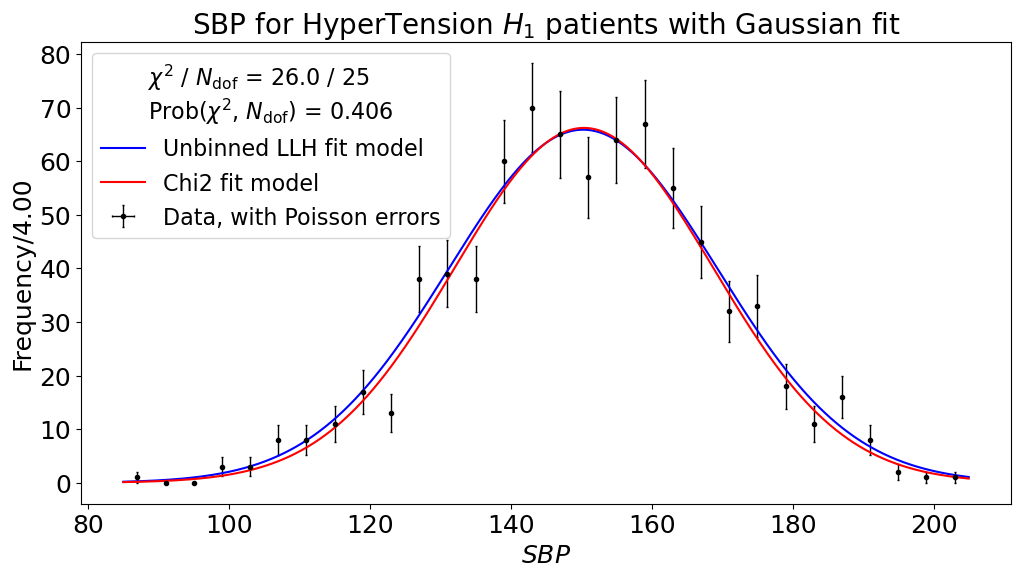

In [23]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.errorbar(x_1, y_1, yerr=sy_1, xerr=0.0, label='Data, with Poisson errors', fmt='.k',  ecolor='k', elinewidth=1, capsize=1, capthick=1)
ax.set_xlabel(r'$SBP$', fontsize=18)
ax.set_ylabel(f'Frequency/{binwidth:.2f}', fontsize=18)
ax.set_title('SBP for HyperTension $H_1$ patients with Gaussian fit', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=18)
xx = np.linspace(xmin_1, xmax_1, 1000)
ax.plot(xx, gauss(xx, *mfitllh_h1.values[:]), '-b', label='Unbinned LLH fit model')
ax.plot(xx, gauss(xx, *mfit2_h1.values[:]), '-r', label='Chi2 fit model')
# Adding fit results to plot:
chi2 = mfit2_h1.fval 
Ndof = len(x1_chi) - mfit2_h1.nfit
Prob = stats.chi2.sf(chi2, Ndof)

fit_info = [f"$\\chi^2$ / $N_\\mathrm{{dof}}$ = {chi2:.1f} / {Ndof}", f"Prob($\\chi^2$, $N_\\mathrm{{dof}}$) = {Prob:.3f}",]

plt.legend(title="\n".join(fit_info), fontsize=16, title_fontsize = 16, alignment = 'center');

#### $H_2$

In [24]:
xmin_2 = 80
xmax_2 = 120
Nbins = 20
binwidth = (xmax_2 - xmin_2) / Nbins

# fig, ax = plt.subplots(figsize=(11, 7))
ax.hist(hypo, bins=Nbins, range=(xmin_2, xmax_2), histtype='step', label='Data')
counts, bin_edges = np.histogram(hypo, bins=Nbins, range=(xmin_2, xmax_2))
x_2 = (bin_edges[1:] + bin_edges[:-1])/2
y_2 = counts    
sy_2 = np.sqrt(counts) 
# ax.errorbar(x_2, y_2, yerr=sy_2, xerr=0.0, label='Data, with Poisson errors', fmt='.k',  ecolor='k', elinewidth=1, capsize=1, capthick=1)

# ax.set_xlabel(r'$SBP$', fontsize=18)
# ax.set_ylabel(f'Frequency/{binwidth:.2f}', fontsize=18)
# ax.set_title('SBP for HypoTension Patients', fontsize=20)
# ax.tick_params(axis='both', which='major', labelsize=18)
# ax.legend(fontsize=18);

In [25]:
x2_chi = x_2[y_2 > 0]
y2_chi = y_2[y_2 > 0]
sy2_chi = sy_2[y_2 > 0]

cfit2_h2 = cost.LeastSquares(x2_chi, y2_chi, sy2_chi, gauss)
mfit2_h2 = Minuit(cfit2_h2, N=len(hypo), mu=np.mean(hypo), sigma=np.std(hypo))
mfit2_h2.migrad()
cfitllh_h2 = cost.ExtendedUnbinnedNLL(hypo, gauss_llh)
mfitllh_h2 = Minuit(cfitllh_h2,  N=len(hypo), mu=np.mean(hypo), sigma=np.std(hypo))
mfitllh_h2.migrad();

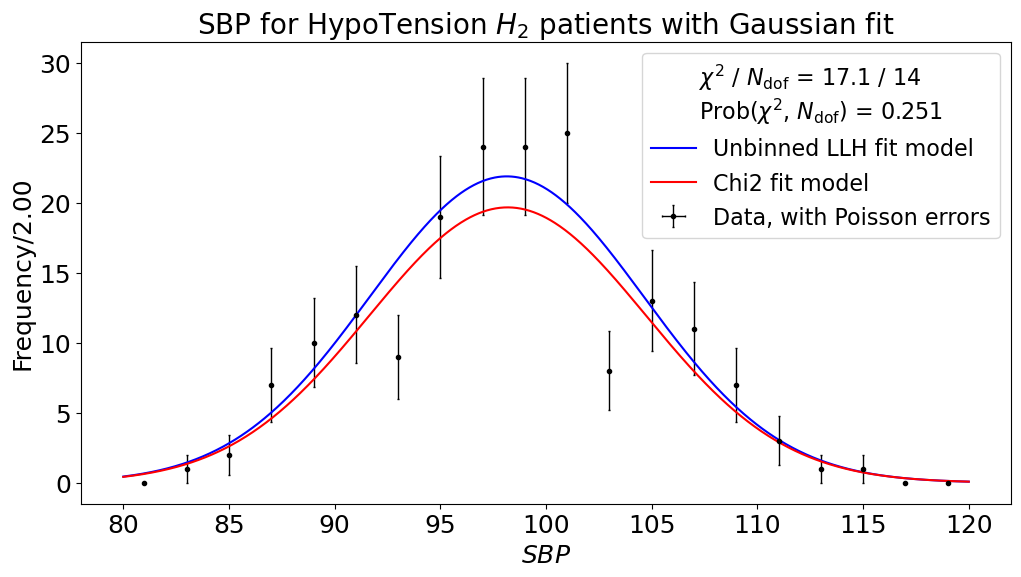

In [26]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.errorbar(x_2, y_2, yerr=sy_2, xerr=0.0, label='Data, with Poisson errors', fmt='.k',  ecolor='k', elinewidth=1, capsize=1, capthick=1)
ax.set_xlabel(r'$SBP$', fontsize=18)
ax.set_ylabel(f'Frequency/{binwidth:.2f}', fontsize=18)
ax.set_title('SBP for HypoTension $H_2$ patients with Gaussian fit', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=18)
xx = np.linspace(xmin_2, xmax_2, 1000)
ax.plot(xx, gauss(xx, *mfitllh_h2.values[:]), '-b', label='Unbinned LLH fit model')
ax.plot(xx, gauss(xx, *mfit2_h2.values[:]), '-r', label='Chi2 fit model')
# Adding fit results to plot:
chi2 = mfit2_h2.fval 
Ndof = len(x2_chi) - mfit2_h2.nfit
Prob = stats.chi2.sf(chi2, Ndof)

fit_info = [f"$\\chi^2$ / $N_\\mathrm{{dof}}$ = {chi2:.1f} / {Ndof}", f"Prob($\\chi^2$, $N_\\mathrm{{dof}}$) = {Prob:.3f}",]

plt.legend(title="\n".join(fit_info), fontsize=16, title_fontsize = 16, alignment = 'center');

#### Fitting with a triple Gauss

In [27]:
def triple_gauss(x, N1, mu1, sigma1, N2, mu2, sigma2, N3, mu3, sigma3):
    gauss1 = N1 * stats.norm.pdf(x, mu1, sigma1)
    gauss2 = N2 * stats.norm.pdf(x, mu2, sigma2)
    gauss3 = N3 * stats.norm.pdf(x, mu3, sigma3)
    return (gauss1 + gauss2 + gauss3) * binwidth

def triple_gauss_llh(x, N1, mu1, sigma1, N2, mu2, sigma2, N3, mu3, sigma3):
    gauss1 = N1 * stats.norm.pdf(x, mu1, sigma1)
    gauss2 = N2 * stats.norm.pdf(x, mu2, sigma2)
    gauss3 = N3 * stats.norm.pdf(x, mu3, sigma3)
    return N1 + N2 + N3, (gauss1 + gauss2 + gauss3)

In [28]:
Ns_guess     = [mfitllh_h0.values[0], mfitllh_h1.values[0], mfitllh_h2.values[0]]
mus_guess    = [mfitllh_h0.values[1], mfitllh_h1.values[1], mfitllh_h2.values[1]]
print(mus_guess)
sigmas_guess = [mfitllh_h0.values[2], mfitllh_h1.values[2], mfitllh_h2.values[2]]
# flatten into a single list
p0 = Ns_guess + mus_guess + sigmas_guess 

cfit2 = cost.LeastSquares(x_chi, y_chi, sy_chi, triple_gauss)
mfit2 = Minuit(cfit2, *p0)
mfit2.migrad();

cfitllh = cost.ExtendedUnbinnedNLL(bloodp, triple_gauss_llh)
mfitllh = Minuit(cfitllh, *p0)
mfitllh.limits[1] = (115, 125)
mfitllh.limits[4] = (145, 155)
mfitllh.limits[7] = (95, 105)
mfitllh.migrad();

[120.66366601434451, 150.26111817026683, 98.14269662921349]


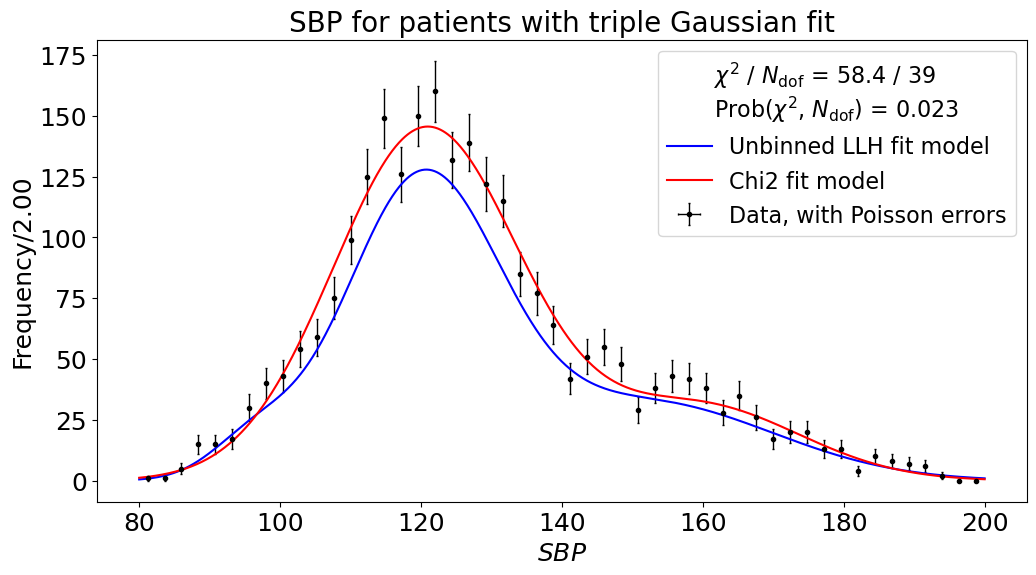

In [29]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.errorbar(x, y, yerr=sy, xerr=0.0, label='Data, with Poisson errors', fmt='.k',  ecolor='k', elinewidth=1, capsize=1, capthick=1)
ax.set_xlabel(r'$SBP$', fontsize=18)
ax.set_ylabel(f'Frequency/{binwidth:.2f}', fontsize=18)
ax.set_title('SBP for patients with triple Gaussian fit', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=18)
xx = np.linspace(xmin, xmax, 1000)
ax.plot(xx, triple_gauss(xx, *mfitllh.values[:]), '-b', label='Unbinned LLH fit model')
ax.plot(xx, triple_gauss(xx, *mfit2.values[:]), '-r', label='Chi2 fit model')
# Adding fit results to plot:
chi2 = mfit2.fval 
Ndof = len(x_chi) - mfit2.nfit
Prob = stats.chi2.sf(chi2, Ndof)

fit_info = [f"$\\chi^2$ / $N_\\mathrm{{dof}}$ = {chi2:.1f} / {Ndof}", f"Prob($\\chi^2$, $N_\\mathrm{{dof}}$) = {Prob:.3f}",]

plt.legend(title="\n".join(fit_info), fontsize=16, title_fontsize = 16, alignment = 'center');

In [ ]:
r.seed(42)
llh_N1, llh_mu1, llh_sig1, llh_N2, llh_mu2, llh_sig2, llh_N3, llh_mu3, llh_sig3 = mfitllh.values[:]
N_experiments = 1000
llh_vals = np.zeros(N_experiments)
N1, N2, N3 = int(llh_N1), int(llh_N2), int(llh_N3)

x1_all = r.normal(llh_mu1, llh_sig1, size=(N_experiments, N1))
x2_all = r.normal(llh_mu2, llh_sig2, size=(N_experiments, N2))
x3_all = r.normal(llh_mu3, llh_sig3, size=(N_experiments, N3))

for i in range(len(llh_vals)) :
    x_vals = np.concatenate((x1_all[i], x2_all[i], x3_all[i]))
    cllhfit_sim = cost.ExtendedUnbinnedNLL(x_vals, triple_gauss_llh)
    mfitllh_sim = Minuit(cllhfit_sim, *p0)
    mfitllh_sim.limits[1] = (115, 125)
    mfitllh_sim.limits[4] = (145, 155)
    mfitllh_sim.limits[7] = (95, 105)
    mfitllh_sim.migrad(ncall=500)          
    llh_vals[i] = mfitllh_sim.fval

P-value from LLH distribution: 0.7330


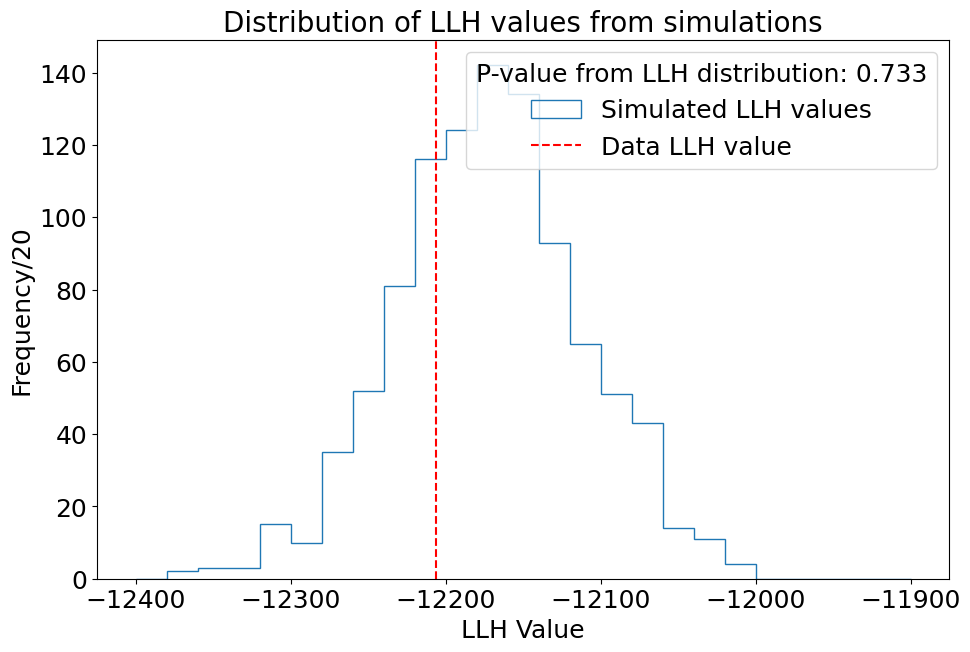

In [ ]:
N_bins_llh = 25
p_value = np.mean(llh_vals >= mfitllh.fval)
print(f"P-value from LLH distribution: {p_value:.4f}")
fit_info = [f"P-value from LLH distribution: {p_value:.3f}"]
x_min_llh, x_max_llh = -12400, -11900
binwidth_llh = (x_max_llh - x_min_llh) / N_bins_llh
fig, ax = plt.subplots(figsize=(11, 7))
ax.hist(llh_vals, bins=N_bins_llh, range=(x_min_llh, x_max_llh), histtype='step', label='Simulated LLH values')
ax.axvline(mfitllh.fval, color='r', linestyle='dashed', label='Data LLH value')
ax.set_xlabel('LLH Value', fontsize=18)
ax.set_ylabel(f'Frequency/{binwidth_llh:.0f}', fontsize=18)
ax.set_title('Distribution of LLH values from simulations', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=18)
plt.legend(title="\n".join(fit_info), fontsize=18, title_fontsize = 18, alignment = 'center', loc='upper right');